# Fogler P12-7: Solution



## Learning Objectives
- Derive an adiabatic energy balance
- Calculate heat of reaction from heats of formation
- Develop T(X) for an adiabatic reactor
- Use the Arrhenius equation to determine k(T)
- Create a Levenspiel plot for an adiabatic reactor and compare it with the Levenspiel plot for an isothermal reactor
- Compare one large CSTR with two smaller CSTRs in series

Given Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [ ]:
T0=300.15
CA0=0.1
v0=2.0
FA0=v0*CA0
HfA=-20
HfB=-15
HfC=-41
CPA=0.015
CPB=0.015
CPC=0.03
E=10
k_ref=0.01
Tref=300
R=1.986e-3

## Question 1: Arrhenius equation, rate law, concentration equations

$$k(T) = k_{ref}\exp\left(\left(\frac{E}{R}\right)\left(\frac{1}{T_{ref}}-\frac{1}{T}\right)\right)$$

$$-r_A = k(T)C_AC_B$$

$$C_A = C_{A0}(1-X)$$

$$C_B = C_A$$

In [ ]:
def k_of_T(T):
    return k_ref*np.exp(E/R*(1/Tref - 1/T))

In [ ]:
def CA(X):
  return CA0*(1-X)

## Question 2: Calculate the Heat of Reaction

In [ ]:
Hrxn = HfC - HfA - HfB
print("Delta H_rxn =",Hrxn,"kcal/mol")

Delta H_rxn = -6 kcal/mol


For this reaction,

$$\Delta H^{rxn} = -6 \ \mathrm{kcal/mol} $$

indicating an exothermic reaction.

## Question 3: Derive the Adiabatic Energy Balance

For this adiabatic liquid-phase reactor:

$$T = T_0 + \frac{(-\Delta H^{rxn})X}{C_{P,A}+C_{P,B}}$$

In [ ]:
def T_of_X(X):
    return T0 + (-Hrxn)*X/(CPA+CPB)

In [ ]:
def nrA(X):
  T = T_of_X(X)
  return k_of_T(T)*CA(X)**2

## Question 5: Determine T when X = 1

In [ ]:
T_at_1 = T_of_X(1)
print("T(1) = ",T_at_1," K")

T(1) =  500.15  K


## Question 6: Create the Levenspiel Plot

In [ ]:
def lev(X):
  return FA0/nrA(X)

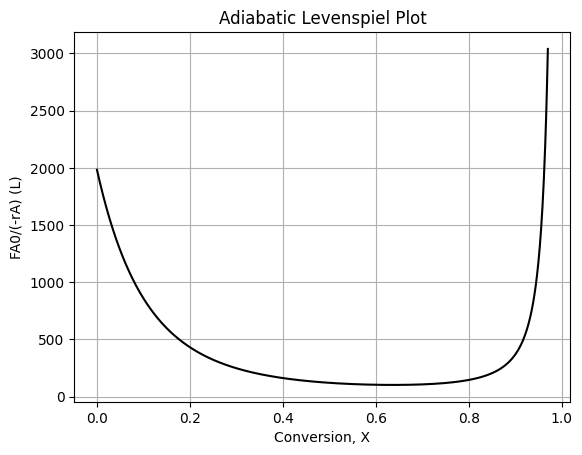

In [ ]:
x_list = np.linspace(0, 0.97, 1001)
y_list = lev(x_list)

plt.plot(x_list,y_list,"k-")
plt.xlabel("Conversion, X")
plt.ylabel("FA0/(-rA) (L)")
plt.title("Adiabatic Levenspiel Plot")
plt.grid()
plt.show()

## Question 7

Notice that the curve initially decreases because the temperature increase accelerates the reaction. At high conversion, reactant depletion dominates, decreasing the rate, and the Levenspiel curve rises sharply.

## Step 8: One 100-dm³ CSTR

In [ ]:
def cstr_vol(X):
  return (X-X0)*lev(X)

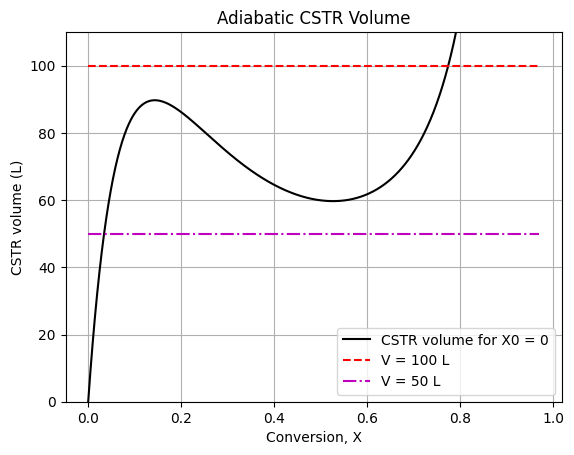

In [ ]:
X0 = 0
x_list = np.linspace(0, 0.97, 1001)
y_list = cstr_vol(x_list)

plt.plot(x_list,y_list,"k-",label="CSTR volume for X0 = 0")
plt.plot(x_list,100*np.ones(len(x_list)),"r--",label="V = 100 L")
plt.plot(x_list,50*np.ones(len(x_list)),"m-.",label="V = 50 L")
plt.xlabel("Conversion, X")
plt.ylabel("CSTR volume (L)")
plt.ylim(0,100*1.1)
plt.title("Adiabatic CSTR Volume")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def objective(X):
  return cstr_vol(X)-Vtarget

In [ ]:
Vtarget=100
root = root_scalar(objective, bracket=[0.6,0.8])
X_for_one_CSTR = root.root
print("Approximate conversion = ",X_for_one_CSTR)

Approximate conversion =  0.7744679971665703


## Step 9: Two 50-dm³ CSTRs in Series

### CSTR 1:

In [ ]:
Vtarget=50
root = root_scalar(objective, bracket=[0.0,0.2])
X_for_two_CSTRs_cstr1 = root.root
print("Approximate conversion = ",X_for_two_CSTRs_cstr1)

Approximate conversion =  0.034162187607304724


### CSTR 2:

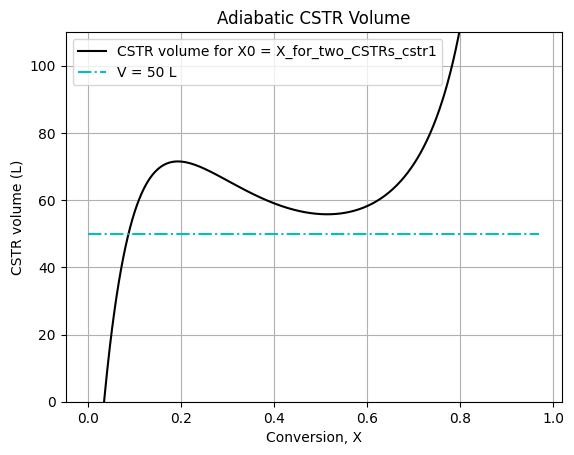

In [ ]:
X0=X_for_two_CSTRs_cstr1
y_list = cstr_vol(x_list)

plt.plot(x_list,y_list,"k-",label="CSTR volume for X0 = X_for_two_CSTRs_cstr1")
plt.plot(x_list,50*np.ones(len(x_list)),"c-.",label="V = 50 L")
plt.xlabel("Conversion, X")
plt.ylabel("CSTR volume (L)")
plt.ylim(0,100*1.1)
plt.title("Adiabatic CSTR Volume")
plt.legend()
plt.grid()
plt.show()

In [ ]:
root = root_scalar(objective, bracket=[0.0,0.2])
X_for_two_CSTRs_cstr2 = root.root
print("Approximate conversion = ",X_for_two_CSTRs_cstr2)

Approximate conversion =  0.08675099469330651


### Analysis

The solution shows one 100-dm³ CSTR gives a much higher conversion than two 50-dm³ CSTRs in series. This is because the larger CSTR capitalizes on the hotter temperature that's achieved. The first smaller CSTR has to operate at a relatively cold temperature and hence slow rate. Hence, it doesn't use its volume effectively.